In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import collections
import pathlib

from construct import *

import sys
sys.path.append('../Tianwen')

import ccsds

plt.rcParams['figure.figsize'] = (7, 3.5)
plt.rcParams['figure.facecolor'] = 'w'

In [2]:
frame_size = 892
cadu_size = 1024
syncword_size = 4

def load_frames(filename):
    frames = np.fromfile(filename, dtype='uint8')
    frames = frames[:frames.size//cadu_size*cadu_size].reshape(-1, cadu_size)
    frames = frames[:, syncword_size:syncword_size+frame_size]  
    return frames

all_files = sorted(pathlib.Path('bochum').glob('**/*.cadu'))

all_frames = [load_frames(f) for f in all_files]
frames = np.concatenate([load_frames(f) for f in all_files])

# filter out some bad frames
keep = (frames[:, 0] == 123) & (frames[:, 1] == 65)
print(np.sum(~keep))
frames = frames[keep]

1


## AOS frames

Frames are AOS Space Data Link frames, using spacecraft ID `0xed`. This spacecraft ID [appears in the SANA registry](https://sanaregistry.org/r/spacecraftid/records/16436). Only Virtual channel 1 is in use. There is no Operational Control Field or Frame Error Control Field (already stripped in GNU Radio). There is an 8 byte insert zone with unknown contents. The data field carries CCSDS SpacePackets using M_PDU.

In [3]:
AOSInsertZone = Struct(
    'unknown' / BytesInteger(8),
)

AOSInsertZone = Struct(
    'timestamp' / BytesInteger(6, swapped=True), # in units of 2**(-16) seconds
    'unknown' / Hex(Int16ub)
)

AOSFrame = Struct(
    'primary_header' / ccsds.AOSPrimaryHeader,
    'insert_zone' / AOSInsertZone,
    'm_pdu_header' / ccsds.M_PDU_Header,
    'm_pdu_packet_zone' / GreedyBytes
)

In [4]:
aos = [AOSFrame.parse(f) for f in frames]

In [5]:
collections.Counter([a.primary_header.transfer_frame_version_number for a in aos])

Counter({1: 46799})

In [6]:
collections.Counter([a.primary_header.spacecraft_id for a in aos])

Counter({237: 46799})

In [7]:
collections.Counter([a.primary_header.virtual_channel_id for a in aos])

Counter({1: 46799})

In [8]:
vcfc = np.array([a.primary_header.virtual_channel_frame_count for a in aos])

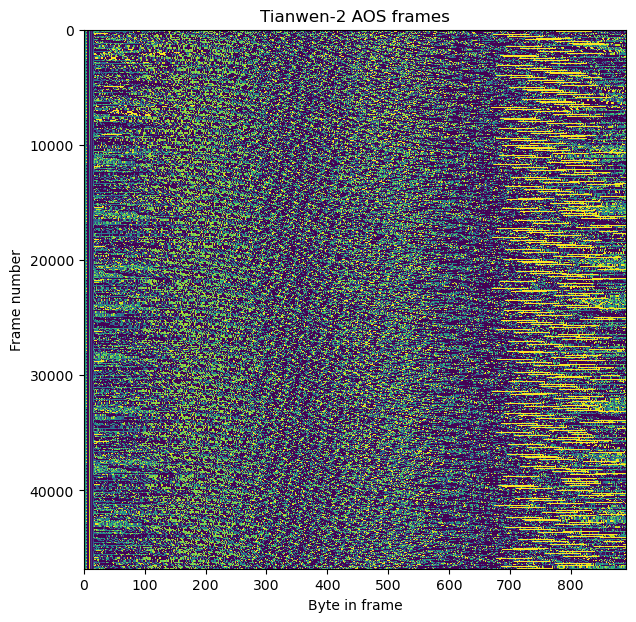

In [9]:
plt.figure(figsize=(7,7))
plt.imshow(frames, aspect='auto', interpolation='none')
plt.title('Tianwen-2 AOS frames')
plt.xlabel('Byte in frame')
plt.ylabel('Frame number');

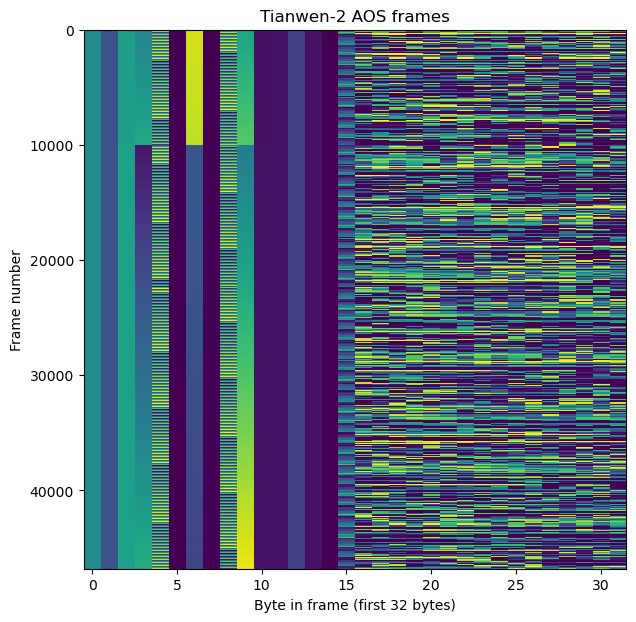

In [10]:
plt.figure(figsize=(7,7))
plt.imshow(frames[:, :32], aspect='auto', interpolation='none')
plt.title('Tianwen-2 AOS frames')
plt.xlabel('Byte in frame (first 32 bytes)')
plt.ylabel('Frame number');

In [11]:
np.all(np.array([a.insert_zone.unknown for a in aos]) == 0x300b)

np.True_

In [12]:
t_aos = np.array([a.insert_zone.timestamp for a in aos])

def timestamps_to_dt64(timestamps):
    return timestamps / 2**16 * 1e9 * np.timedelta64(1, 'ns') + np.datetime64('2019-12-31T16:00')

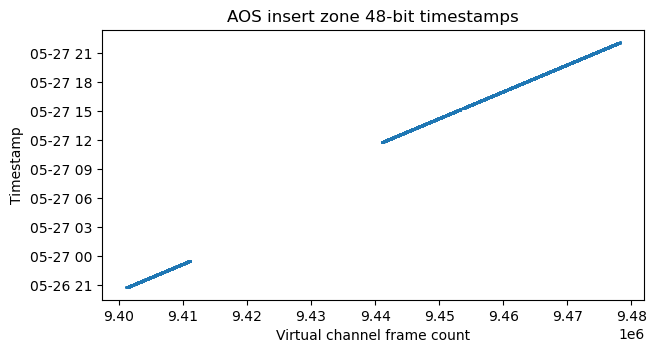

In [13]:
plt.plot(vcfc, timestamps_to_dt64(t_aos), '.', markersize=1)
plt.title('AOS insert zone 48-bit timestamps')
plt.xlabel('Virtual channel frame count')
plt.ylabel('Timestamp');

## Virtual channel 1

Virtual channel 1 carries CCSDS Space Packets. A number of different APIDs are in use. Each APID has packets of the same size. Secondary headers are not used.

In [14]:
packets = list(ccsds.extract_space_packets(aos, 237, 1, get_timestamps=True))

/home/daniel/contracting/tw-2/ccsds.py:93: UserWarning: [Space Packet extractor Spacecraft 237 VC 1] Broken stream. Last frame count 9411147, current frame count 9441030
  warnings.warn(f'[Space Packet extractor Spacecraft {sc_id} VC {virtual_channel}] Broken stream. Last frame count {frame_count}, current frame count {frame_count_new}')
/home/daniel/contracting/tw-2/ccsds.py:93: UserWarning: [Space Packet extractor Spacecraft 237 VC 1] Broken stream. Last frame count 9453329, current frame count 9453336
  warnings.warn(f'[Space Packet extractor Spacecraft {sc_id} VC {virtual_channel}] Broken stream. Last frame count {frame_count}, current frame count {frame_count_new}')
/home/daniel/contracting/tw-2/ccsds.py:93: UserWarning: [Space Packet extractor Spacecraft 237 VC 1] Broken stream. Last frame count 9453336, current frame count 9453651
  warnings.warn(f'[Space Packet extractor Spacecraft {sc_id} VC {virtual_channel}] Broken stream. Last frame count {frame_count}, current frame count 

In [15]:
headers = [ccsds.SpacePacketPrimaryHeader.parse(p[0]) for p in packets]

In [16]:
headers[:10]

[Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=17, sequence_flags=3, packet_sequence_count_or_name=2291, data_length=38),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=18, sequence_flags=3, packet_sequence_count_or_name=2291, data_length=12),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=19, sequence_flags=3, packet_sequence_count_or_name=2291, data_length=45),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=20, sequence_flags=3, packet_sequence_count_or_name=2291, data_length=25),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=21, sequence_flags=3, packet_sequence_count_or_name=2291, data_length=9),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=272, sequence_flags=3, packet_sequence_count_or_name=8215, data_length=7),
 Container(ccsds_version=0, packet_type=0, secondary_header_flag=False, APID=528, sequenc

In [17]:
apids = collections.Counter([p.APID for p in headers])
apids

Counter({17: 46798,
         18: 46797,
         19: 46797,
         20: 46797,
         21: 46797,
         272: 46797,
         528: 46797,
         1552: 46797,
         32: 46796,
         22: 23399,
         1554: 23399,
         33: 23398,
         34: 23398,
         35: 23398,
         36: 23398,
         26: 14418,
         28: 14418,
         1556: 8095,
         1557: 8094,
         1553: 8094,
         1555: 8092,
         24: 4489,
         25: 4489})

In [18]:
{apid: collections.Counter([p.data_length for p in headers if p.APID == apid]) for apid in apids}

{17: Counter({38: 46798}),
 18: Counter({12: 46797}),
 19: Counter({45: 46797}),
 20: Counter({25: 46797}),
 21: Counter({9: 46797}),
 272: Counter({7: 46797}),
 528: Counter({7: 46797}),
 32: Counter({93: 46796}),
 1552: Counter({175: 46797}),
 33: Counter({9: 23398}),
 34: Counter({16: 23398}),
 35: Counter({99: 23398}),
 36: Counter({87: 23398}),
 1556: Counter({175: 8095}),
 22: Counter({49: 23399}),
 1554: Counter({175: 23399}),
 1557: Counter({175: 8094}),
 26: Counter({12: 14418}),
 28: Counter({20: 14418}),
 1553: Counter({175: 8094}),
 1555: Counter({175: 8092}),
 24: Counter({126: 4489}),
 25: Counter({104: 4489})}

In [19]:
by_apid = {apid: np.array([np.frombuffer(p[0][ccsds.SpacePacketPrimaryHeader.sizeof():], 'uint8')
                           for h, p in zip(headers, packets) if h.APID == apid])
           for apid in apids}
t_by_apid = {apid: timestamps_to_dt64(np.array([p[1] for h, p in zip(headers, packets) if h.APID == apid]))
             for apid in apids}

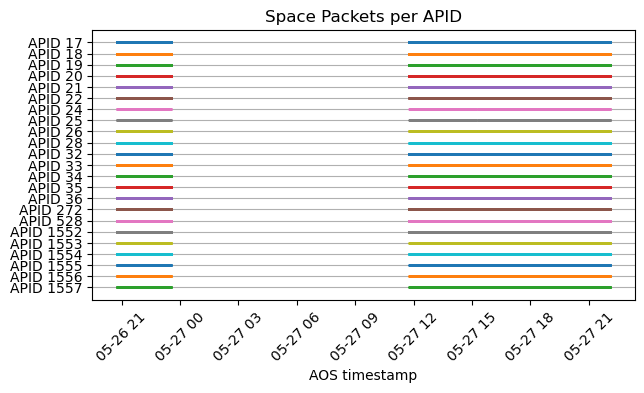

In [20]:
for n, apid in enumerate(sorted(apids)):
    plt.plot(t_by_apid[apid], np.full(t_by_apid[apid].size, -n), '.', markersize=1)
plt.yticks(-np.arange(len(apids)), [f'APID {a}' for a in sorted(apids)])
plt.xticks(rotation=45)
plt.xlabel('AOS timestamp')
plt.title('Space Packets per APID')
plt.grid(axis='y');

/tmp/ipykernel_29178/128914862.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 5))


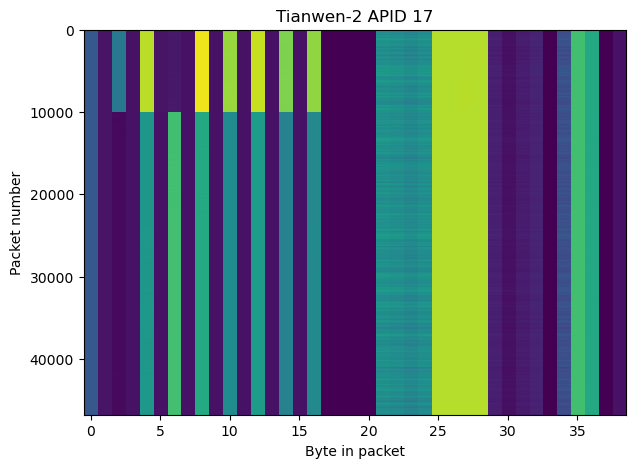

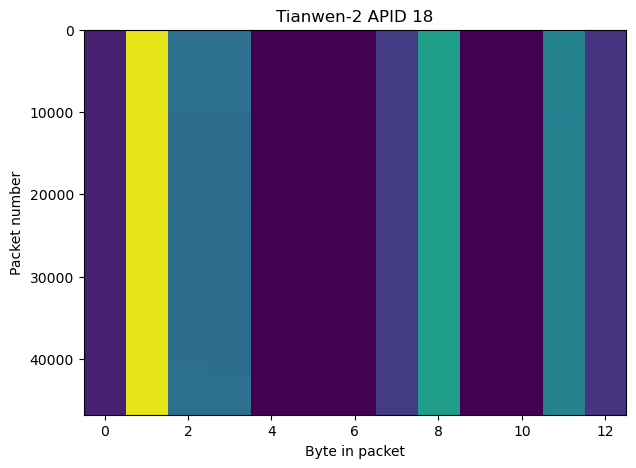

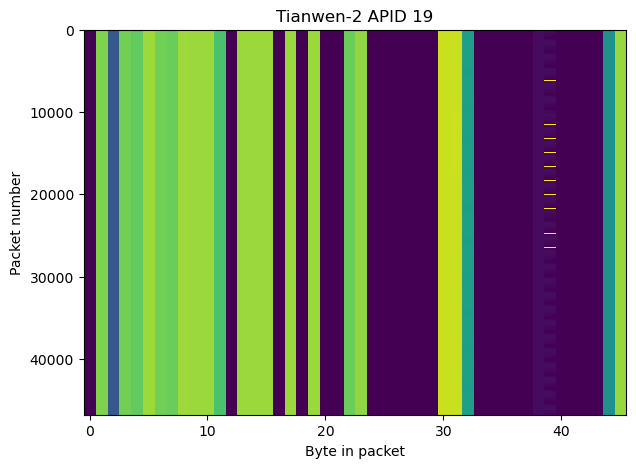

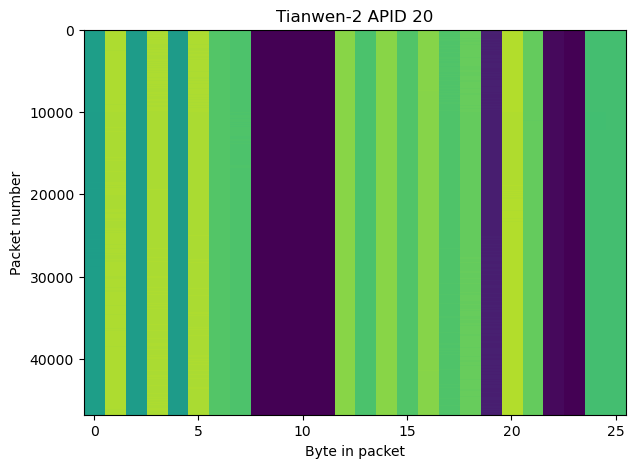

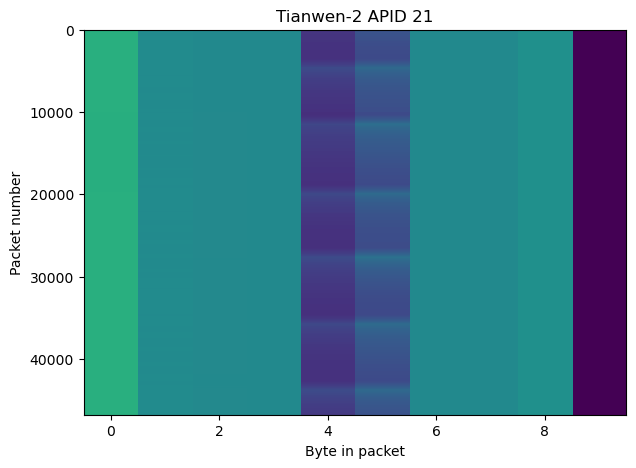

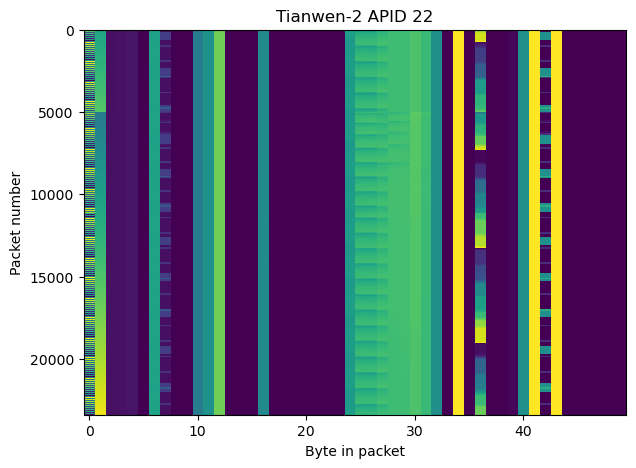

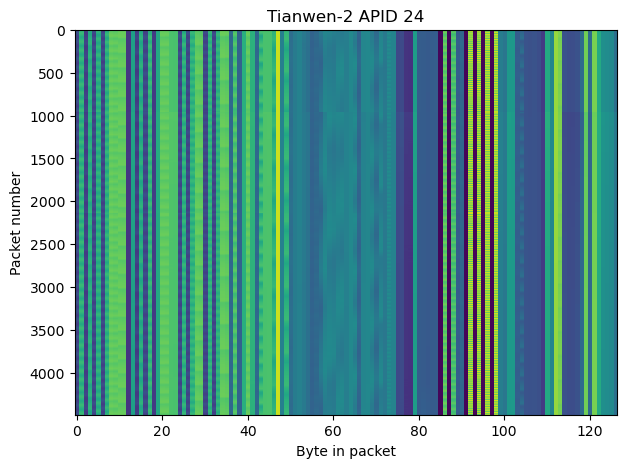

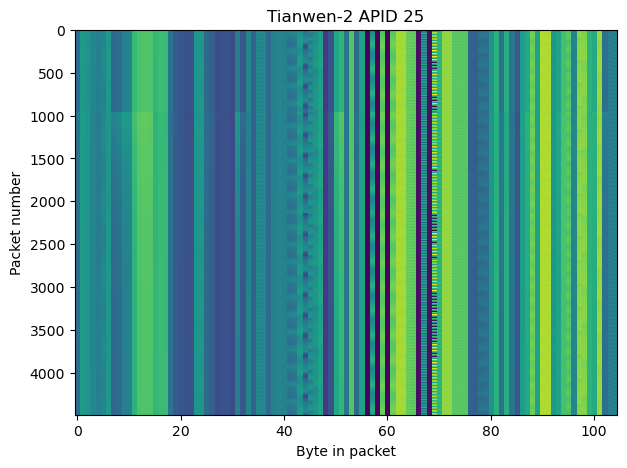

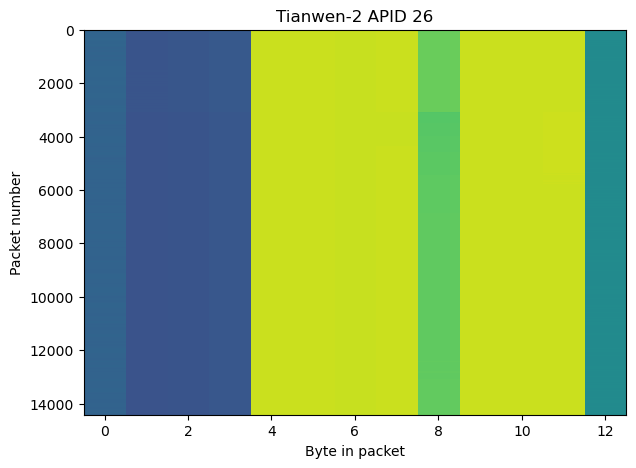

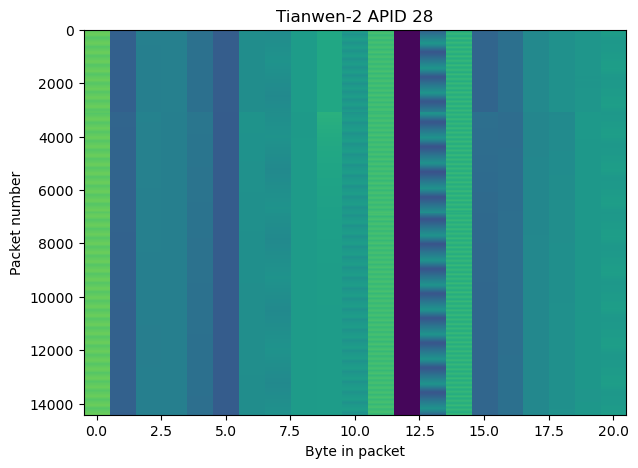

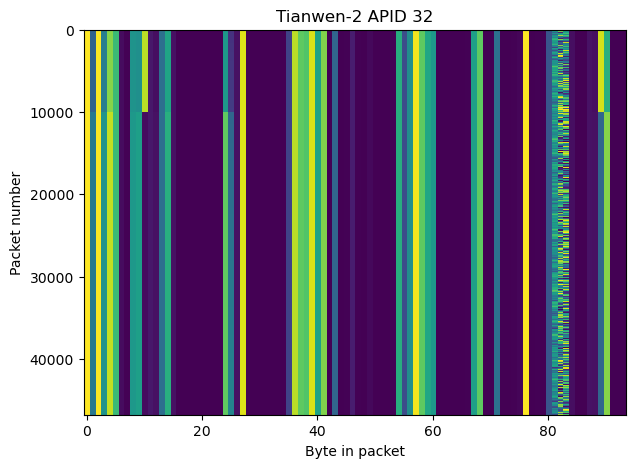

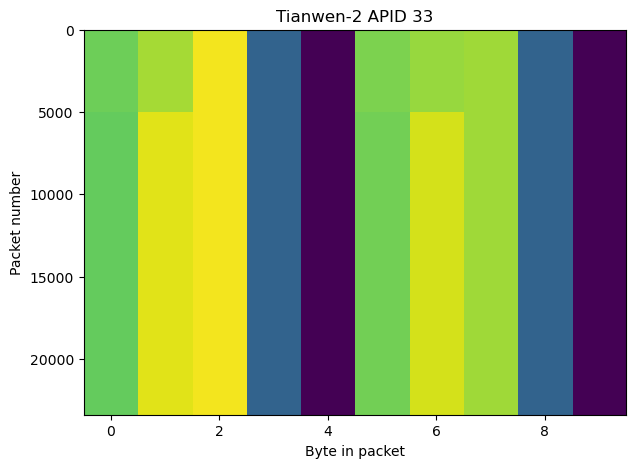

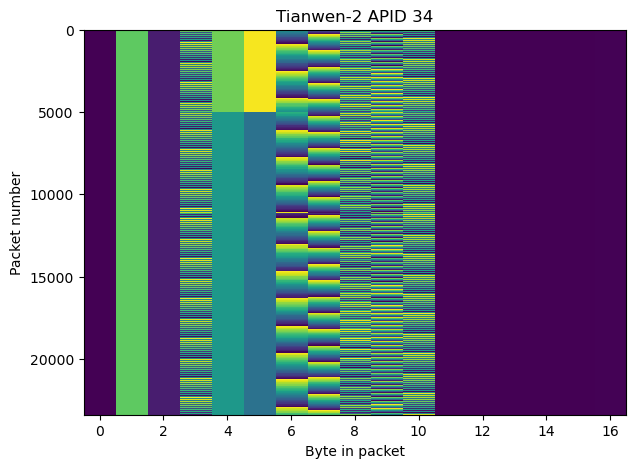

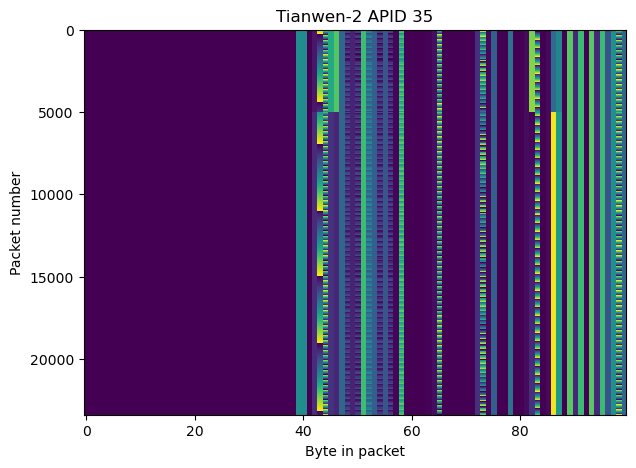

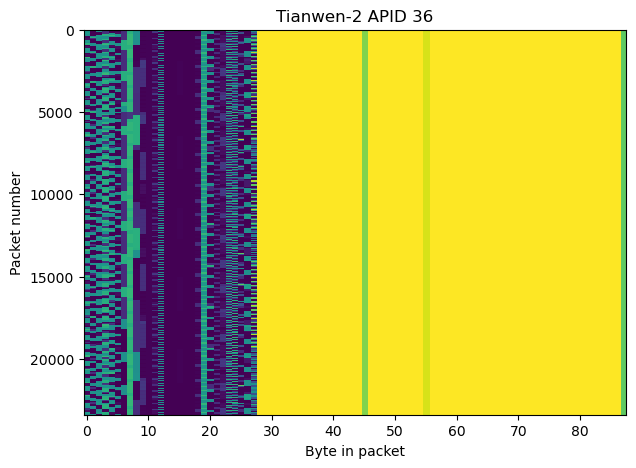

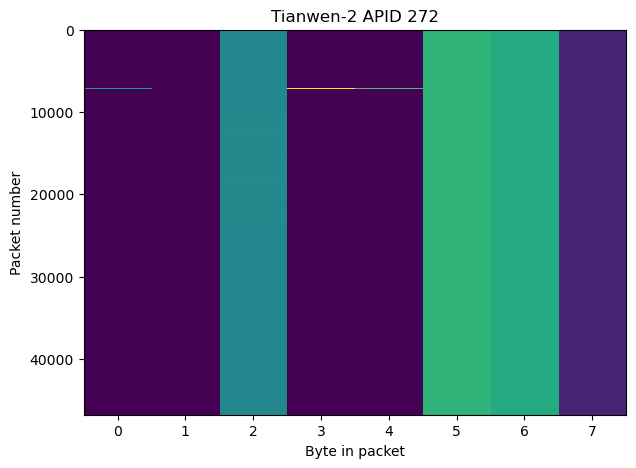

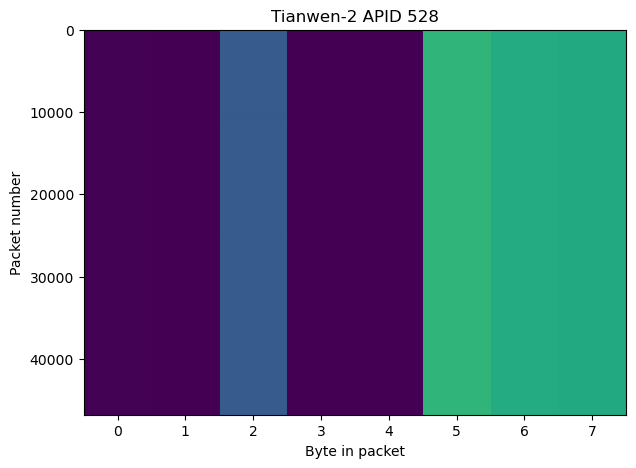

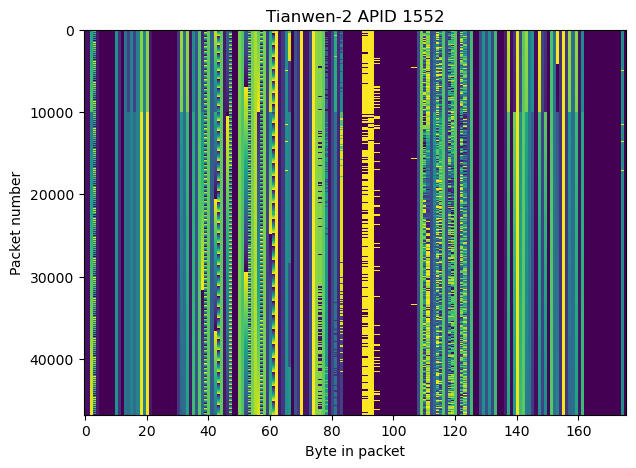

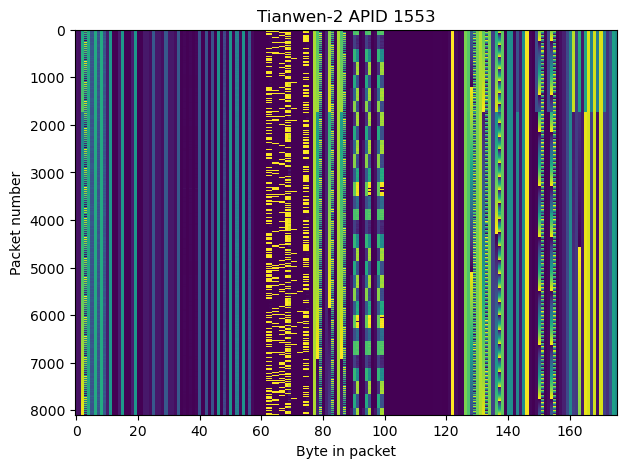

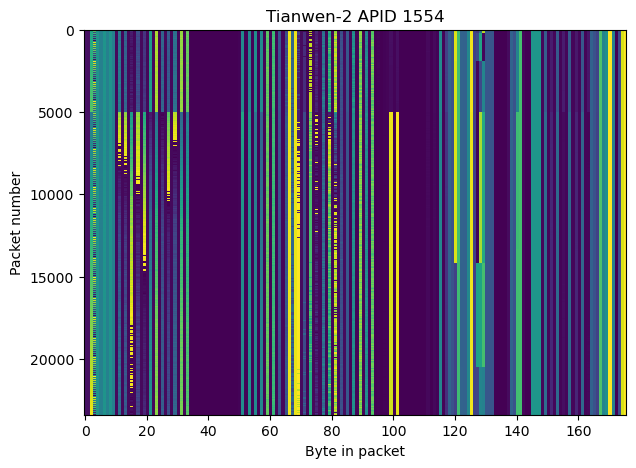

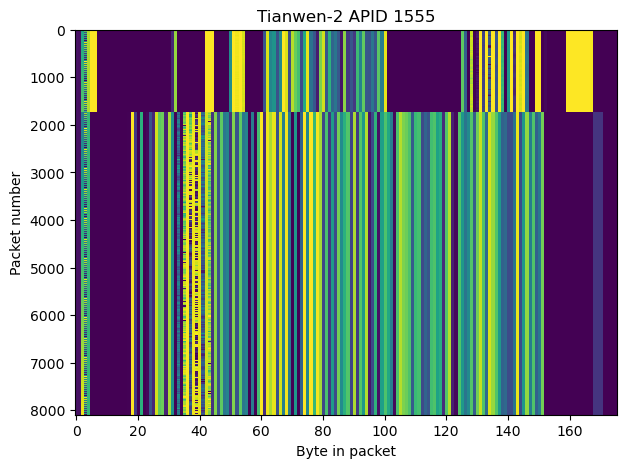

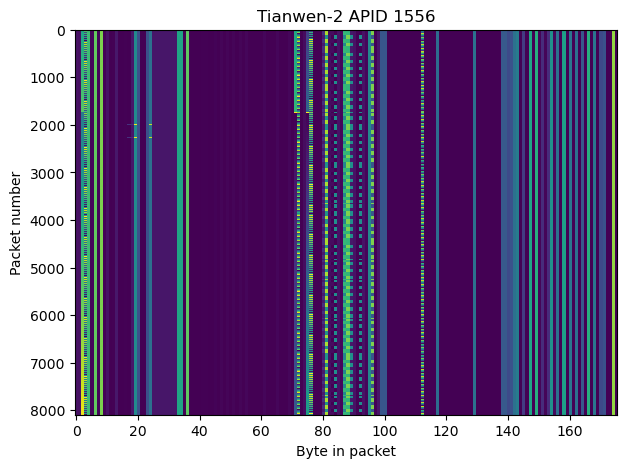

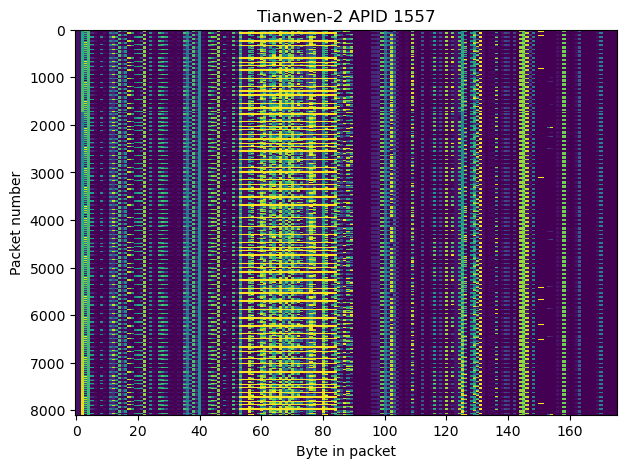

In [21]:
for apid in sorted(apids):
    plt.figure(figsize=(7, 5))
    plt.imshow(by_apid[apid], aspect='auto', interpolation='none', vmin=0, vmax=255)
    plt.title(f'Tianwen-2 APID {apid}')
    plt.ylabel('Packet number')
    plt.xlabel('Byte in packet')

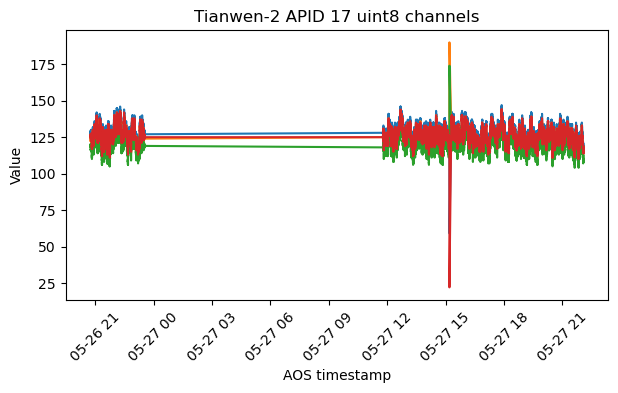

In [22]:
plt.plot(t_by_apid[17], by_apid[17][:, 21:25])
plt.title('Tianwen-2 APID 17 uint8 channels')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);

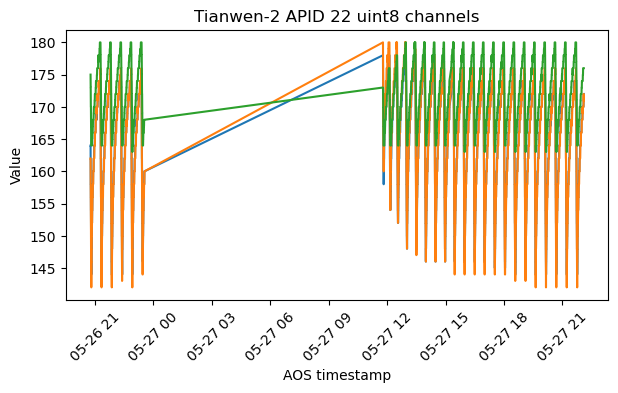

In [23]:
plt.plot(t_by_apid[22], by_apid[22][:, 25:28])
plt.title('Tianwen-2 APID 22 uint8 channels')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);

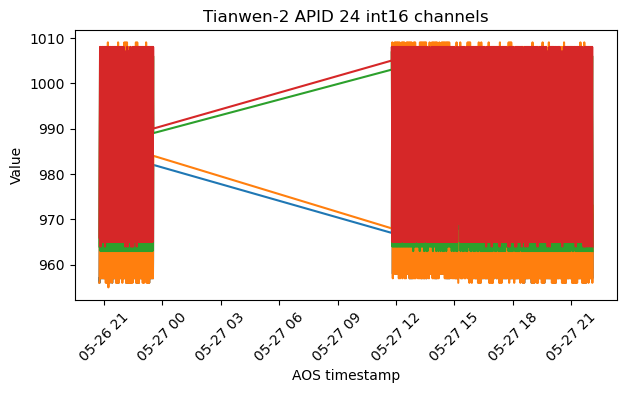

In [24]:
plt.plot(t_by_apid[24], by_apid[24][:, 91:][:, :4*2].view('int16').byteswap())
plt.title('Tianwen-2 APID 24 int16 channels')
plt.xlabel('Packet number')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);

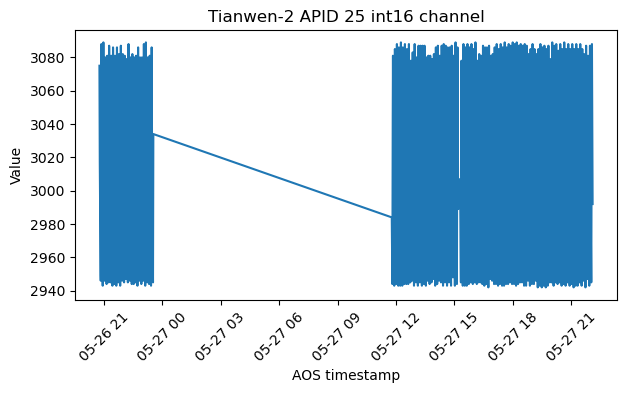

In [25]:
plt.plot(t_by_apid[25], by_apid[25][:, 68:70].view('int16').byteswap())
plt.title('Tianwen-2 APID 25 int16 channel')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);

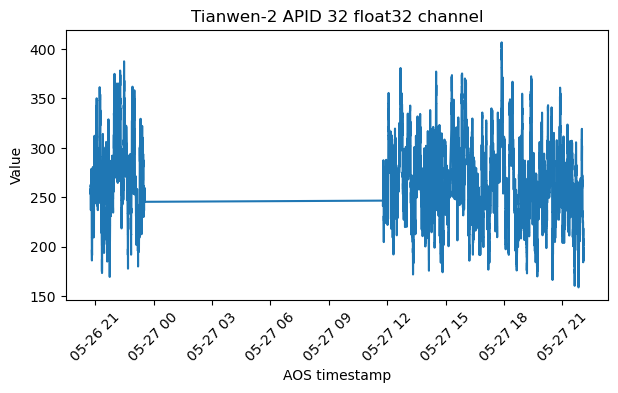

In [26]:
plt.plot(t_by_apid[32], by_apid[32][:, 80:84].view('float32').byteswap())
plt.title('Tianwen-2 APID 32 float32 channel')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);

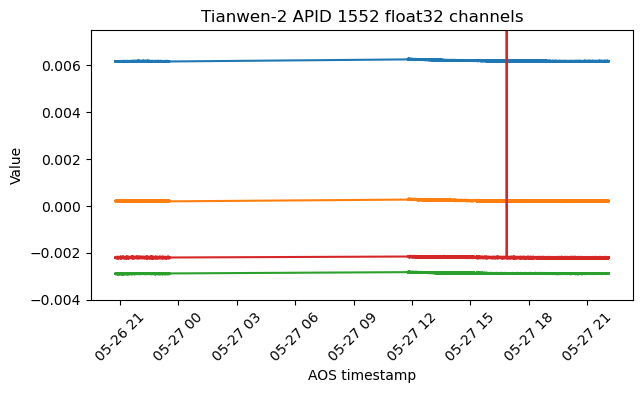

In [32]:
plt.plot(t_by_apid[1552], by_apid[1552][:, 108:][:, :4*4].view('float32').byteswap())
plt.title('Tianwen-2 APID 1552 float32 channels')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.ylim(-0.004, 0.0075);

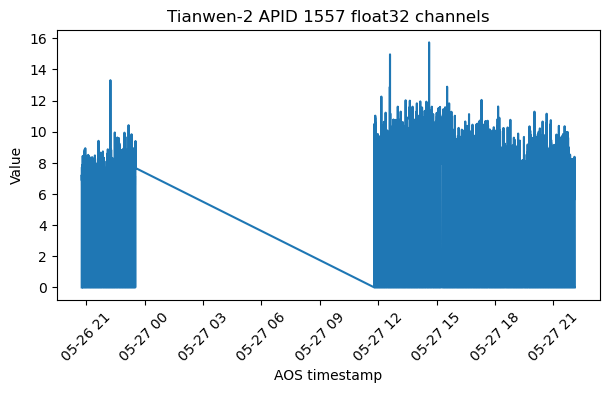

In [28]:
plt.plot(t_by_apid[1557], by_apid[1557][:, 86:][:, :4].view('float32').byteswap())
plt.title('Tianwen-2 APID 1557 float32 channels')
plt.xlabel('AOS timestamp')
plt.ylabel('Value')
plt.xticks(rotation=45);